In [2]:
import jax
import jax.numpy as jnp
from tvboptim.experimental.network_dynamics import Network, solve, prepare
from tvboptim.experimental.network_dynamics.dynamics.tvb import ReducedWongWang
from tvboptim.experimental.network_dynamics.coupling import LinearCoupling, DelayedLinearCoupling
from tvboptim.experimental.network_dynamics.graph import DenseDelayGraph
from tvboptim.experimental.network_dynamics.noise import AdditiveNoise
from tvboptim.experimental.network_dynamics.solvers import Heun, BoundedSolver
from tvboptim.observations.tvb_monitors import Bold, SubSampling
from tvboptim.observations import compute_fc, fc_corr, rmse
from tvboptim.data import load_structural_connectivity, load_functional_connectivity
from tvboptim.types import Parameter
from tvboptim.optim import OptaxOptimizer
from tvboptim.optim.callbacks import DefaultPrintCallback, PrintParameterCallback
import optax

# Load example connectivity data (Desikan-Killiany 84-region parcellation)
# Structural connectivity: white matter connections derived from diffusion MRI
weights, lengths, labels = load_structural_connectivity("dk_average")
weights = weights / jnp.max(weights)  # Normalize connection weights
delays = lengths / 3.0  # Convert tract lengths (mm) to delays (ms) at 3 m/s conduction velocity

# Functional connectivity: empirical correlation patterns from resting-state fMRI
target_fc = load_functional_connectivity("dk_average")

In [3]:
# Build a brain network model with 84 regions
network = Network(
    dynamics=ReducedWongWang(),                     # Neural mass model (local dynamics)
    coupling={'delayed': DelayedLinearCoupling(     # How regions communicate
        incoming_states="S", G=0.5)},
    graph=DenseDelayGraph(weights, delays,          # Structural connectivity + delays
                          region_labels=labels),
    noise=AdditiveNoise(sigma=0.01,                 # Stochastic fluctuations
                        key=jax.random.key(42))
)

# Run 60-second simulation (1 ms time steps)
solver = BoundedSolver(Heun(), low = 0.0, high = 1.0) # Keep S between 0 and 1
result = solve(network, solver, t0=0.0, t1=60_000.0, dt=1.0)

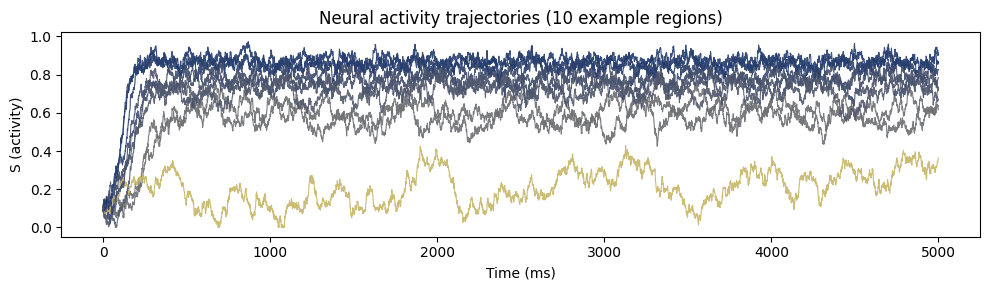

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
# Get n colors from the viridis colormap
n = 10
colors = plt.cm.cividis_r(jnp.mean(result.ys[0:5000, 0, 0:n], axis = 0))
for i, color in enumerate(colors):
    ax.plot(result.ts[0:5000], result.ys[0:5000, 0, i], 
            linewidth=0.8, alpha=0.9, color=color)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('S (activity)')
ax.set_title(f'Neural activity trajectories ({n} example regions)')
plt.tight_layout()
plt.show()

In [7]:
# Optimization workflow: fit coupling strength to match empirical functional connectivity

# Step 1: Prepare for optimization by converting the network to pure function + parameters
network.update_history(result)  # Use simulation result to initialize delay history
simulator, params = prepare(network, solver, t0=0.0, t1=60_000.0, dt=1.0)

# Step 2: Set up BOLD fMRI monitor
# Converts neural activity to BOLD signal via Balloon-Windkessel hemodynamic model
# Sampled every 720 ms (≈1.4 Hz) to match typical fMRI temporal resolution
bold_monitor = Bold(history=result, period=720.0, downsample=SubSampling(period=4.0))

# Step 3: Mark parameter for optimization
params.coupling.delayed.G = Parameter(0.5)

# Compute initial FC for comparison
def get_fc(params):
    """Helper to compute FC from simulation."""
    solution = simulator(params)
    bold = bold_monitor(solution)
    return compute_fc(bold)

fc_initial = get_fc(params)

# Step 4: Define loss and optimize
def loss(params):
    """Loss function using RMSE between predicted and empirical FC."""
    predicted_fc = get_fc(params)
    return rmse(predicted_fc, target_fc)

# Run optimization with Adam optimizer
opt = OptaxOptimizer(loss, optax.adam(learning_rate=0.03), callback=DefaultPrintCallback())
final_params, history = opt.run(params, max_steps=50)

# Compute final FC and print results
fc_final = get_fc(final_params)
print(f"\nOptimization complete: G={final_params.coupling.delayed.G:.3f}")

Step 0: 0.309145
Step 1: 0.282703
Step 2: 0.241408
Step 3: 0.195042
Step 4: 0.167562
Step 5: 0.170190
Step 6: 0.183451
Step 7: 0.193434
Step 8: 0.198607
Step 9: 0.200855
Step 10: 0.198377
Step 11: 0.192211
Step 12: 0.183539
Step 13: 0.174387
Step 14: 0.167487
Step 15: 0.165772
Step 16: 0.169654
Step 17: 0.175583
Step 18: 0.178933
Step 19: 0.178399
Step 20: 0.174536
Step 21: 0.169453
Step 22: 0.166189
Step 23: 0.166015
Step 24: 0.168583
Step 25: 0.171709
Step 26: 0.173826
Step 27: 0.174173
Step 28: 0.174130
Step 29: 0.172418
Step 30: 0.169786
Step 31: 0.167138
Step 32: 0.165704
Step 33: 0.165881
Step 34: 0.167404
Step 35: 0.169136
Step 36: 0.169922
Step 37: 0.169270
Step 38: 0.167352
Step 39: 0.165878
Step 40: 0.165706
Step 41: 0.166594
Step 42: 0.167668
Step 43: 0.167974
Step 44: 0.168052
Step 45: 0.167541
Step 46: 0.166642
Step 47: 0.165868
Step 48: 0.165615
Step 49: 0.165732

Optimization complete: G=0.388


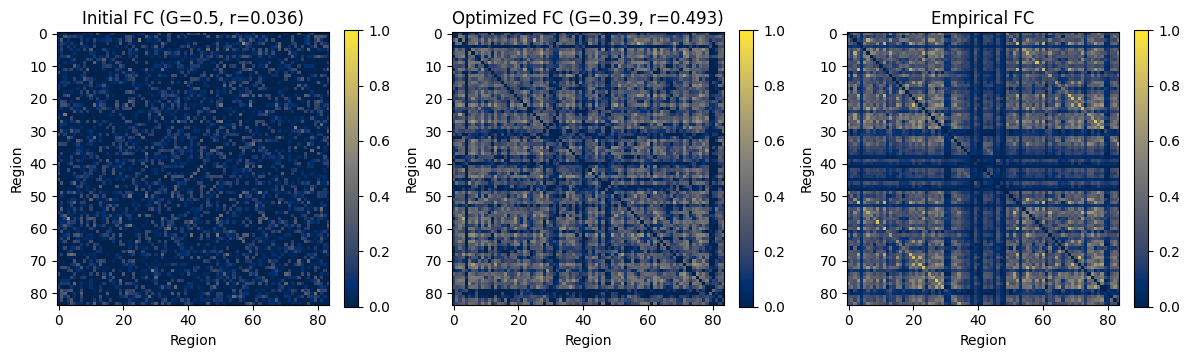

FC correlation improvement: 0.036 → 0.493


In [8]:
# Compute correlations
corr_initial = fc_corr(fc_initial, target_fc)
corr_final = fc_corr(fc_final, target_fc)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# Initial FC
im0 = axes[0].imshow(fc_initial, cmap='cividis', vmin=0, vmax=1)
axes[0].set_title(f'Initial FC (G=0.5, r={corr_initial:.3f})')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Region')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Final FC
im1 = axes[1].imshow(fc_final, cmap='cividis', vmin=0, vmax=1)
axes[1].set_title(f'Optimized FC (G={final_params.coupling.delayed.G:.2f}, r={corr_final:.3f})')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Region')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Target FC
im2 = axes[2].imshow(target_fc, cmap='cividis', vmin=0, vmax=1)
axes[2].set_title('Empirical FC')
axes[2].set_xlabel('Region')
axes[2].set_ylabel('Region')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

# Print correlation improvements
print(f"FC correlation improvement: {corr_initial:.3f} → {corr_final:.3f}")